<a href="https://colab.research.google.com/github/thelbpandit0415/thelb-demo/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Project is on Predict the House Price using Boston dataset**

In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor

# The boston dataset is removed by sklearn so i downloaded it from kaggle

In [ ]:
boston = pd.read_csv('/content/boston.csv')

In [ ]:
print(boston)

        CRIM  INDUS    NOX     RM        AGE     DIS  TAX         PT  \
0    0.00632   2.31  0.538  6.575  65.199997  4.0900  296  15.300000   
1    0.02731   7.07  0.469  6.421  78.900002  4.9671  242  17.799999   
2    0.02729   7.07  0.469  7.185  61.099998  4.9671  242  17.799999   
3    0.03237   2.18  0.458  6.998  45.799999  6.0622  222  18.700001   
4    0.06905   2.18  0.458  7.147  54.200001  6.0622  222  18.700001   
..       ...    ...    ...    ...        ...     ...  ...        ...   
501  0.06263  11.93  0.573  6.593  69.099998  2.4786  273  21.000000   
502  0.04527  11.93  0.573  6.120  76.699997  2.2875  273  21.000000   
503  0.06076  11.93  0.573  6.976  91.000000  2.1675  273  21.000000   
504  0.10959  11.93  0.573  6.794  89.300003  2.3889  273  21.000000   
505  0.04741  11.93  0.573  6.030  80.800003  2.5050  273  21.000000   

              B         MV  
0    396.899994  24.000000  
1    396.899994  21.600000  
2    392.829987  34.700001  
3    394.630005  33

In [ ]:
boston.head()

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
0,0.00632,2.31,0.538,6.575,65.199997,4.0900,296,15.300000,396.899994,24.000000
1,0.02731,7.07,0.469,6.421,78.900002,4.9671,242,17.799999,396.899994,21.600000
2,0.02729,7.07,0.469,7.185,61.099998,4.9671,242,17.799999,392.829987,34.700001
3,0.03237,2.18,0.458,6.998,45.799999,6.0622,222,18.700001,394.630005,33.400002
4,0.06905,2.18,0.458,7.147,54.200001,6.0622,222,18.700001,396.899994,36.200001


In [ ]:
boston.shape

(506, 10)

In [ ]:
boston.isnull().sum()

,0
CRIM,0
INDUS,0
NOX,0
RM,0
AGE,0
DIS,0
TAX,0
PT,0
B,0
MV,0


In [ ]:
boston.describe()

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674030,22.532806
std,8.601545,6.860353,0.115878,0.702617,28.148862,2.105710,168.537116,2.164946,91.294863,9.197104
min,0.006320,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,5.000000
25%,0.082045,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377487,17.025000
50%,0.256510,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440002,21.200001
75%,3.677083,18.100000,0.624000,6.623500,94.074999,5.188425,666.000000,20.200001,396.225006,25.000000
max,88.976196,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.899994,50.000000


In [ ]:
correlation = boston.corr()

<Axes: >

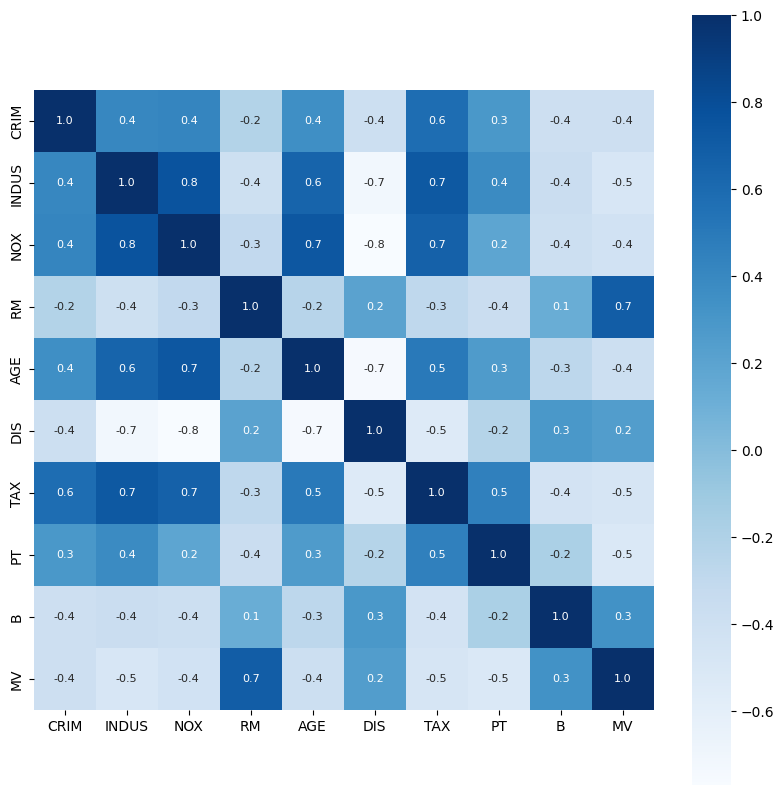

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [ ]:
x = boston.drop(['MV'],axis=1)
y = boston['MV']

In [ ]:
print(x)
print(y)

        CRIM  INDUS    NOX     RM        AGE     DIS  TAX         PT  \
0    0.00632   2.31  0.538  6.575  65.199997  4.0900  296  15.300000   
1    0.02731   7.07  0.469  6.421  78.900002  4.9671  242  17.799999   
2    0.02729   7.07  0.469  7.185  61.099998  4.9671  242  17.799999   
3    0.03237   2.18  0.458  6.998  45.799999  6.0622  222  18.700001   
4    0.06905   2.18  0.458  7.147  54.200001  6.0622  222  18.700001   
..       ...    ...    ...    ...        ...     ...  ...        ...   
501  0.06263  11.93  0.573  6.593  69.099998  2.4786  273  21.000000   
502  0.04527  11.93  0.573  6.120  76.699997  2.2875  273  21.000000   
503  0.06076  11.93  0.573  6.976  91.000000  2.1675  273  21.000000   
504  0.10959  11.93  0.573  6.794  89.300003  2.3889  273  21.000000   
505  0.04741  11.93  0.573  6.030  80.800003  2.5050  273  21.000000   

              B  
0    396.899994  
1    396.899994  
2    392.829987  
3    394.630005  
4    396.899994  
..          ...  
501  391.

In [ ]:
#Splitting data in training data and test data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1,random_state=2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(506, 9) (455, 9) (51, 9)


In [ ]:
#Model Training
#Loading the Model
model = XGBRegressor()

In [ ]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Predicting on training data
training_data_prediction = model.predict(x_train)

In [ ]:
print(training_data_prediction)

[30.703236   4.9894185 35.38122   27.863054  18.367104  18.549675
 17.538326  15.60643   22.426792  20.26829   20.588552  19.735815
 28.168213  35.11039   27.417706  48.53109   27.517992  11.50817
 22.016243  13.190469   7.399393  20.560745  20.098455  25.156046
 21.991209  19.145552  24.278233  19.397478  23.918571  34.906723
 19.421234  21.38268   26.60357   37.680473  35.994854  21.342802
 23.611725  24.814407  19.902979  20.808418  18.166658  10.899573
 43.981228  43.52194    8.313111  46.708324  32.89093   21.722887
 14.383817  29.125145  23.777271  23.159744  20.942408  20.100176
 34.702114  13.909888  13.508762  21.993921  15.205397  10.913611
 22.614918  13.774502   5.54587   29.795668  50.052483  34.866425
 20.63159   23.330875  19.216099  32.679394  19.562641  26.946009
  8.395233  45.995743  21.809273  27.06739   19.39197   19.307446
 24.792555  22.622894  31.741524  18.574884   8.697688  17.474262
 23.693905  13.271364  10.509915  12.681086  25.00122   19.66122
 14.935603  

In [ ]:
#Using R Square
score1 = metrics.r2_score(y_train, training_data_prediction)

# Mean square error
score2 = metrics.mean_squared_error(y_train, training_data_prediction)

In [ ]:
print("The r Squared error is: ",score1)
print('The mean square error is: ',score2)

The r Squared error is:  0.9999832133917862
The mean square error is:  0.0014359087049086703


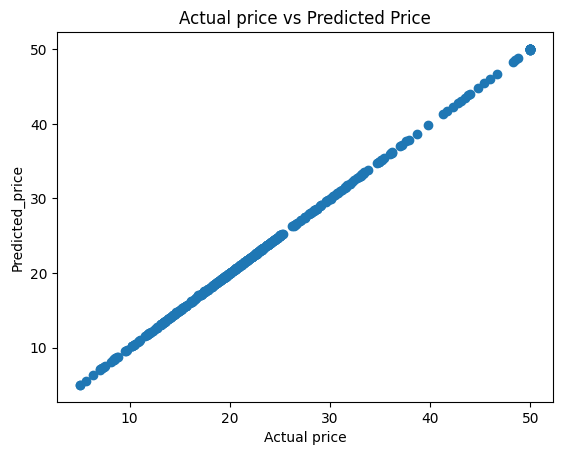

In [ ]:
#Visualizing actual price vs Predicted Price
plt.scatter(y_train,training_data_prediction)
plt.xlabel("Actual price")
plt.ylabel("Predicted_price")
plt.title("Actual price vs Predicted Price")
plt.show()

In [ ]:
#prediction on test data
test_data_prediction = model.predict(x_test)

In [ ]:
#Using R Square
score3 = metrics.r2_score(y_test,test_data_prediction)

# Mean square error
score4 = metrics.mean_squared_error(y_test, test_data_prediction)